# Simple Scheduling Algorithm using QAOA



N tasks    \
M workers  \
M <= N     

Assign tasks to workers    \
Each task assigned only to one worker

input  - Weight matrix, W \
output - optimized scheuling of tasks to workers resulting a least cost \
                      \
W(i, j) indicate the cost of jth task assigned to ith worker



### QAOA procedure for Simple Scheduling

1. Weight matrix to QUBO Cost

2. QUBO Cost to Hamiltonian

3. QAOA Circuit
    * QAOA Ansatz
    * Transpile to Aer Simulator circuit

4. Optimization
    * Estimator for evaluating Energy or Cost
    * Classical parameter optimization through minimize function

5. Results
    * Generate Sampler output of the circuit assigned with best parameters
    * Optimal Scheduling
    * Visualization



In [6565]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\kcrav\miniconda3\envs\myenv\python.exe
Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [6566]:
#!jupyter kernelspec list

In [6567]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from scipy.optimize import minimize

## Weight matrix to Classical QUBO Cost




In [6568]:
N = 5
M = 2
p_reps = 2

init_param_values = []

if p_reps == 4:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5]
elif p_reps == 3:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 5]
elif p_reps == 2:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 5, np.pi/4.5]
elif p_reps == 1:
    init_param_values = [np.pi / 3, np.pi / 6]

assert N > 0 and M > 0, "N and M must be positive integers."
#assert N >= M, "N must be greater than or equal to M for a valid scheduling problem."

def generate_weight_matrix(M, N):
    w = np.random.randint(1, 100, size=(M, N))
    return w

w = generate_weight_matrix(M, N)
print('w:', w)

w_col = w.reshape(-1, 1)


w: [[73 11 48 21 27]
 [51 10 49 67 67]]


In [6569]:
'''
L = 10*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N
Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
for i in range(M * N):
    for j in range(int(np.floor(i/M)*M),i):
        Q[i, j] = 2*L
C = 0.00001*w_col - L*np.ones((M * N, 1))

#print(np.diag(Q))
#print(np.diag(np.diag(Q)))
#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero

print('Q:', Q)
print('C:', C)
'''

"\nL = 10*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N\nQ = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones\nfor i in range(M * N):\n    for j in range(int(np.floor(i/M)*M),i):\n        Q[i, j] = 2*L\nC = 0.00001*w_col - L*np.ones((M * N, 1))\n\n#print(np.diag(Q))\n#print(np.diag(np.diag(Q)))\n#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero\n\nprint('Q:', Q)\nprint('C:', C)\n"

In [6570]:
L = 1*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N
Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
for j in range(N):
    for i in range(M):
        for l in range(i):
            #Q[i * N + j, l * N + j] = 2/(N)
            Q[i * N + j, l * N + j] = 1/(N)
            Q[l * N + j, i * N + j] = 1/(N)
            #Q[i * N + j, l * N + j] = 2*L
            #Q[i * N + j, l * N + j] = L
            #Q[l * N + j, i * N + j] = L
C = w_col/(np.sum(w_col)) - 1/(N)*np.ones((M * N, 1))
#C = w_col*(.5/(2*L)) - .5*np.ones((M * N, 1))
#C = .1*w_col - L*np.ones((M * N, 1))

#print(np.diag(Q))
#print(np.diag(np.diag(Q)))
#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero


print('Q:', Q)
print('C:', C)

Q: [[0.  0.  0.  0.  0.  0.2 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.2 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.2 0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.2 0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.2]
 [0.2 0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.2 0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.2 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.2 0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.2 0.  0.  0.  0.  0. ]]
C: [[-0.02783019]
 [-0.1740566 ]
 [-0.08679245]
 [-0.1504717 ]
 [-0.13632075]
 [-0.07971698]
 [-0.17641509]
 [-0.08443396]
 [-0.04198113]
 [-0.04198113]]


In [6571]:
def qubo_cost_function(x, Q, C):
    return 0.5 * x.T @ Q @ x + C.T @ x


# brute-force search for CLASSICAL optimal solution
min_cost = 100000
min_bitstring = None
max_cost = -100000
max_bitstring = None
for i in range(2**(M*N)):
    x = np.array(list(np.binary_repr(i, width=M*N)), dtype=int)
    cost = qubo_cost_function(x, Q, C)
    #print(f"x: {x}, cost: {cost}")
    #print(f"x: {x}, x.T @ Q @ x: {x.T @ Q @ x}, C.T @ x: {C.T @ x}")
    if cost < min_cost:
        min_cost = cost
        min_bitstring = x
    if cost > max_cost:
        max_cost = cost
        max_bitstring = x

#print(f"Maximum cost: {max_cost}, achieved by bitstring: {max_bitstring}, \n reshaped bitstring: \n {max_bitstring.reshape(M, N)}")
print(f"Minimum cost: {min_cost}, achieved by bitstring: {min_bitstring}, \n reshaped bitstring: \n {min_bitstring.reshape(M, N)}")
print('w:', w)
print('w_col: \n', w_col)

Minimum cost: [-0.62971698], achieved by bitstring: [0 0 1 1 1 1 1 0 0 0], 
 reshaped bitstring: 
 [[0 0 1 1 1]
 [1 1 0 0 0]]
w: [[73 11 48 21 27]
 [51 10 49 67 67]]
w_col: 
 [[73]
 [11]
 [48]
 [21]
 [27]
 [51]
 [10]
 [49]
 [67]
 [67]]


## Classical QUBO to Hamiltonian




In [6572]:
C[1][0], Q[5,:]

(np.float64(-0.17405660377358492),
 array([0.2, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]))

In [6573]:
def classical_qubo_to_hamiltonian(Q, C):
    n = len(C)
    pauli_list = []
    
    for i in range(n):
        if C[i] != 0 or np.sum(Q[i,:]) != 0:
            pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/4 + np.sum(Q[:,i])/4 + C[i][0]/2)))
            #pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/2 + C[i][0]/2)))
            pass
    
    for i in range(n):
        for j in range(i):
            if Q[i, j] != 0:
                pauli_list.append(('ZZ', [i, j], np.float64(Q[i, j]/4)))
                pauli_list.append(('ZZ', [j, i], np.float64(Q[j, i]/4)))
                pass
    
    return pauli_list

In [6574]:
pauli_list = classical_qubo_to_hamiltonian(Q, C)
no_of_qubits = M * N
Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=no_of_qubits)
Cost_hamiltonian

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII', 'IIIIZIIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIZI', 'IIIZIIIIZI', 'IIZIIIIZII', 'IIZIIIIZII', 'IZIIIIZIII', 'IZIIIIZIII', 'ZIIIIZIIII', 'ZIIIIZIIII'],
              coeffs=[-0.08608491+0.j, -0.0129717 +0.j, -0.05660377+0.j, -0.02476415+0.j,
 -0.03183962+0.j, -0.06014151+0.j, -0.01179245+0.j, -0.05778302+0.j,
 -0.07900943+0.j, -0.07900943+0.j,  0.05      +0.j,  0.05      +0.j,
  0.05      +0.j,  0.05      +0.j,  0.05      +0.j,  0.05      +0.j,
  0.05      +0.j,  0.05      +0.j,  0.05      +0.j,  0.05      +0.j])


## QAOA Circuit

### QAOA Ansatz


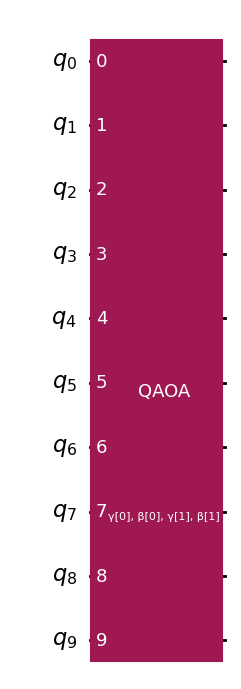

In [6575]:
circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)
#circuit.measure_all()

circuit.draw("mpl")

In [6576]:
#circuit.decompose().draw("mpl")


### Transpile to Aer Simulator circuit


In [6577]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [6578]:
binding_dict = {param: value for param, value in zip(circuit.parameters, init_param_values)}
bound_circuit = circuit.assign_parameters(binding_dict)
bound_circuit.parameters

ParameterView([])

In [6579]:
simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

Aer_transpiled_ckt.save_statevector()

#Aer_transpiled_ckt.draw("mpl")

### State vector simulation (checking for initial parameters)

In [6580]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(binding_dict)

results = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results.get_counts()
#plot_histogram(counts, title="State Vector without measurement")

In [6581]:
state_vector = results.get_statevector()

#plot_state_city(state_vector, title="State Vector City Plot")

## Optimization

### Estimator for evaluating Energy or Cost



In [6582]:
obj_fn_costs_iter = []
parameter_values_iter = []

In [6583]:
def Average_Energy(parameter_values, transpiled_circuit, Cost_hamiltonian, estimator):
    # Bind the parameters to the circuit
    binding_dict = {param: value for param, value in zip(transpiled_circuit.parameters, parameter_values)}
    #bound_circuit = transpiled_circuit.assign_parameters(binding_dict)

    #isa_hamiltonian = Cost_hamiltonian.apply_layout(bound_circuit.layout)
    isa_hamiltonian = Cost_hamiltonian.apply_layout(transpiled_circuit.layout)

    #display(bound_circuit.draw("mpl"))

    # Simulate the circuit to get the state vector
    #simulator = AerSimulator(method='statevector')
    #transpiled_ckt = transpile(bound_circuit, simulator)

    #print(Cost_hamiltonian)
    #print(isa_hamiltonian)
    
    #print(transpiled_circuit.parameters)
    #print(len(transpiled_circuit.parameters))

    #print(bound_circuit.parameters)
    #print(len(bound_circuit.parameters))

    pub = (transpiled_circuit, isa_hamiltonian, parameter_values)
    #pub = (bound_circuit, isa_hamiltonian, parameter_values)
    results = estimator.run([pub]).result()

    #print(results[0].data.evs)

    #state_vector = results[0].get_statevector()


    # Compute the expectation value of the cost Hamiltonian
    #stateVect = np.array(state_vector)
    #cost_Mx = np.array(Cost_hamiltonian.to_matrix())
    #energy = np.real(stateVect.conj().T @ cost_Mx @ stateVect)

    #print("Expected Values:", results[0].data.evs)
    #print("Energy:", energy)

    obj_fn_costs_iter.append(results[0].data.evs)
    parameter_values_iter.append(list(parameter_values))


    return results[0].data.evs # energy

### Parameter optimization through minimize function

Hybrid Quantum-Classical workflow
- Parameter optimization - Classical processing
- Energy calculation - QPU/Simulator


Optimal parameters: [ 2.77294332 -0.11214594  1.766988    0.4603074 ]
Minimum energy: -0.2589147315835053


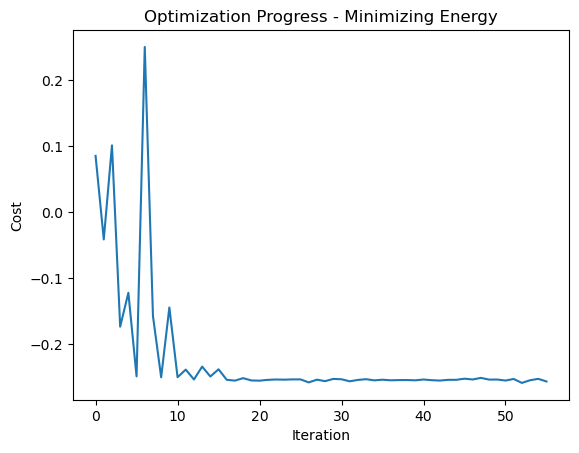

In [6584]:
obj_fn_costs_iter = []
parameter_values_iter = []

simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

estimator = Estimator(mode=simulator)
estimator.options.default_shots = 1024*16

param_values_init = [0.77254496, 1.24810316] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = [2.30713335, 0.9512575 ] # [.002, .01] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = init_param_values

result = minimize(
        Average_Energy,
        param_values_init,
        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-6,
        #options={'rhobeg': .0001},
)

optimal_parameters = result.x
optimal_energy = result.fun

print("Optimal parameters:", result.x)
print("Minimum energy:", result.fun)

plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()

In [6585]:
parameter_values = [-0.913, -1.248]
parameter_values = [-0.8, -1.2481]
parameter_values = [10000/L, 1.2481]

estimator.options.default_shots = 1024*32
isa_hamiltonian = Cost_hamiltonian.apply_layout(Aer_transpiled_ckt.layout)

In [6586]:
'''parameter_values = [553/L, 1.2481] # [100000/L, 1.2481]

pub = (Aer_transpiled_ckt, Cost_hamiltonian, parameter_values)
results = estimator.run([pub]).result()

results[0].data.evs '''

'parameter_values = [553/L, 1.2481] # [100000/L, 1.2481]\n\npub = (Aer_transpiled_ckt, Cost_hamiltonian, parameter_values)\nresults = estimator.run([pub]).result()\n\nresults[0].data.evs '

In [6587]:
'''
from qiskit_algorithms.optimizers import ADAM
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import QAOA
from qiskit_aer import Aer

backend = Aer.get_backend("statevector_simulator")
qaoa = QAOA(optimizer = ADAM(maxiter=200, lr=0.01), sampler=backend, initial_point=init_param_values, reps = 1)
eigen_optimizer = MinimumEigenOptimizer(min_eigen_solver=qaoa)

eigen_optimizer.solve(Cost_hamiltonian)
'''

'\nfrom qiskit_algorithms.optimizers import ADAM\nfrom qiskit_optimization.algorithms import MinimumEigenOptimizer\nfrom qiskit_algorithms import QAOA\nfrom qiskit_aer import Aer\n\nbackend = Aer.get_backend("statevector_simulator")\nqaoa = QAOA(optimizer = ADAM(maxiter=200, lr=0.01), sampler=backend, initial_point=init_param_values, reps = 1)\neigen_optimizer = MinimumEigenOptimizer(min_eigen_solver=qaoa)\n\neigen_optimizer.solve(Cost_hamiltonian)\n'

In [6588]:
list(zip(parameter_values_iter, obj_fn_costs_iter))

history = []
history = ([[float(round(parameter_values_iter[i][0],8)), float(round(parameter_values_iter[i][1],8)), round(float(obj_fn_costs_iter[i]),3)] for i in range(len(parameter_values_iter))])

print('  gama,  beta,  cost')
history

  gama,  beta,  cost


[[1.04719755, 0.78539816, 0.085],
 [2.04719755, 0.78539816, -0.041],
 [2.04719755, 1.78539816, 0.101],
 [2.04719755, 0.78539816, -0.174],
 [2.04719755, 0.78539816, -0.122],
 [2.58021526, 0.18557309, -0.249],
 [3.1329473, 0.74374543, 0.25],
 [1.83582334, -0.45578782, -0.158],
 [2.7685667, -0.0631373, -0.25],
 [2.98190408, -0.01166341, -0.145],
 [2.74971185, -0.06677217, -0.25],
 [2.70828321, -0.13575741, -0.239],
 [2.7864644, -0.08696127, -0.254],
 [2.73939277, -0.03174395, -0.234],
 [2.87475742, -0.10820588, -0.249],
 [2.79018556, -0.05551914, -0.238],
 [2.77581127, -0.08977813, -0.254],
 [2.77649765, -0.1132489, -0.255],
 [2.77395312, -0.13352702, -0.252],
 [2.77832661, -0.11281155, -0.255],
 [2.77142887, -0.11216255, -0.256],
 [2.77901305, -0.11204908, -0.254],
 [2.77140521, -0.11710148, -0.254],
 [2.7681956, -0.10319355, -0.254],
 [2.76901543, -0.11647383, -0.254],
 [2.77085247, -0.11200844, -0.254],
 [2.77294266, -0.11214628, -0.258],
 [2.77375064, -0.11159899, -0.254],
 [2.7725987

In [6589]:
print("Optimal parameters, minimum energy:")
[float(round(optimal_parameters[0],3)), float(round(optimal_parameters[1],3)), round(float(optimal_energy),3)] 

Optimal parameters, minimum energy:


[2.773, -0.112, -0.259]

## Results


### Generate Sampler output of the circuit assigned with best parameters


In [6590]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
bound_Aer_transpiled_ckt.measure_all()

#display(bound_Aer_transpiled_ckt.draw("mpl"))

sampler = Sampler(mode=simulator)
sampler.options.default_shots = 1024*16
result = sampler.run([bound_Aer_transpiled_ckt]).result()
#print("result:", result)

print(result[0].data.meas.get_counts())

#print(result[0].data.keys(), result[0].data.values(), result[0].data.ndim, result[0].data.shape, result[0].data.size)

'''
bit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))
Probabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]
plt.bar(bit_strings, Probabilites)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Probability')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()

plot_histogram(result[0].data.meas.get_counts(), title="Measurement results with optimal parameters with #layers = " + str(p_reps))

'''

{'0010011010': 74, '0010110110': 18, '1011101001': 23, '0101111000': 13, '1010101000': 46, '0000011010': 50, '0011000001': 46, '0111010000': 61, '0100110100': 40, '1001100101': 11, '1110000000': 29, '0110110010': 61, '1010001010': 59, '0011001001': 55, '0100010010': 47, '0011001000': 43, '0101010001': 57, '0110010010': 44, '0100001100': 5, '1101100010': 18, '1000100110': 48, '0010011011': 75, '0010000001': 18, '1101100100': 53, '1110000010': 58, '1110110010': 22, '0100110011': 15, '1000100011': 4, '1110001010': 12, '0011010101': 12, '1100000010': 25, '0010100010': 47, '0001001100': 44, '0000101100': 31, '0001111100': 93, '0001001101': 35, '1000001010': 44, '0100000110': 41, '0111000000': 42, '1001001101': 63, '1010000011': 45, '1111000000': 51, '0110010001': 37, '1100101110': 19, '0100000010': 32, '0111010101': 13, '0010011000': 44, '0000111100': 53, '1011011110': 4, '0100101100': 11, '0011100100': 12, '0011011100': 21, '0001110110': 17, '1111000001': 54, '0010001001': 23, '0110100010'

'\nbit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))\nProbabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]\nplt.bar(bit_strings, Probabilites)\nplt.xlabel(\'Partition (binary representation)\')\nplt.ylabel(\'Probability\')\nplt.title(\'Measurement results with optimal parameters with #layers = \' + str(p_reps))\nplt.xticks(rotation=90)\nplt.show()\n\nplot_histogram(result[0].data.meas.get_counts(), title="Measurement results with optimal parameters with #layers = " + str(p_reps))\n\n'

In [6591]:
'''
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)

results_StateVector = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results_StateVector.get_counts()
plot_histogram(counts, title="State Vector without measurement")
'''

'\nbound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)\n\nresults_StateVector = simulator.run(bound_Aer_transpiled_ckt).result()\ncounts = results_StateVector.get_counts()\nplot_histogram(counts, title="State Vector without measurement")\n'

### Optimal Scheduling


In [6592]:
frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))
'''
plt.bar(bit_strings, frequencies)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Frequency')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()
'''


"\nplt.bar(bit_strings, frequencies)\nplt.xlabel('Partition (binary representation)')\nplt.ylabel('Frequency')\nplt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))\nplt.xticks(rotation=90)\nplt.show()\n"


### Visualization

In [6593]:
#f=L/10
#plt.plot(np.sin(np.arange(0, 1, 0.001)*f*2*np.pi))



In [6594]:
print("Optimal parameters, minimum energy:")
[float(round(optimal_parameters[0],3)), float(round(optimal_parameters[1],3)), round(float(optimal_energy),3)] 

Optimal parameters, minimum energy:


[2.773, -0.112, -0.259]

In [6595]:
bit_strings_output = []

for ir in range(len(bit_strings)):
    bit_strings_output.append([int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))])
    bit_strings_output[ir].reverse()
    matched_idx = ir
    for i in range(len(bit_strings_output[ir])):
        if bit_strings_output[ir][i] != min_bitstring[i]:
            matched_idx = None
            break
    if matched_idx is not None:
        break

#bit_strings_output = [int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))]
#bit_strings_output = np.flip(bit_strings_output)

print('w:\n',w)
print('c:\n',min_bitstring.reshape(M, N))
print('q:\n',np.array(bit_strings_output[0]).reshape(M, N))

print(f"\n Solution at matched_idx: \n {matched_idx}  of {len(bit_strings)} of {2**((M*N))}")


w:
 [[73 11 48 21 27]
 [51 10 49 67 67]]
c:
 [[0 0 1 1 1]
 [1 1 0 0 0]]
q:
 [[0 0 0 1 1]
 [1 1 1 0 0]]

 Solution at matched_idx: 
 2  of 976 of 1024
